# Notebook to explore photocentre movements

For paper3. To extract statistics on how the photocentre of an AGB star moves depending
on amount of dust in front of it in images, and for adapting and exploring GAIA data on
AGB stars. To extract photocentre movements of GAIA data.

## Extract Image photocentre

Inspired by the work by Beguin et al 2023 and 2024. Coords of photocentre is an
intensity weighted mean of the xy-positions of all emitting pixels in the image.
Formalised as

  Px = sum_x( sum_y( Image(x,y) * xcoord(x,y))) / sum_x( sum_y( Image(x,y) ))
  Px = sum_x( sum_y( Image(x,y) * ycoord(x,y))) / sum_x( sum_y( Image(x,y) ))

where Image(x,y) are all the pixel fluxes of the image and xcoord and ycoord are all
physical coordinates of the pixels of the images.


-0.07691745881662257 0.1991613097754044
-0.046616641707043986 0.1207038241063057


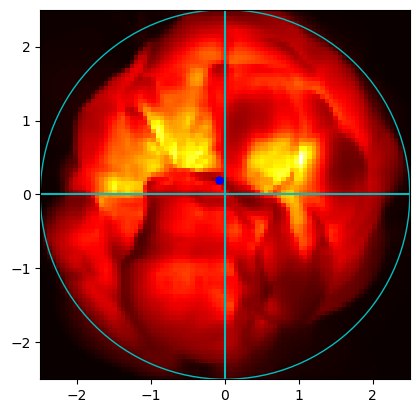

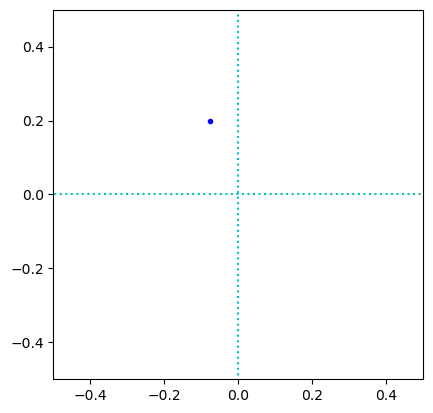

In [ ]:
# Test with only one snapshot and one image
import analyze_r3d_functions as a3d
import matplotlib.pyplot as plt
import numpy as np

modelname = 'st28gm06n052_timedep_nodust'
snapshot = '250'
angle = 'i000_phi000'
wavelength = '02'
beamradius = 2.5
# Gaia beam size at 2um is between 1.01 and 0.34 asec
# at 100pc : 101 to 34 au. So the 30x30 image size is not bad to use

image2d,image2dlog,totalflux,axisplot = a3d.load_images(
    path=f'../r3dresults/{modelname}/{snapshot}/',
    image=f'image_{angle}_{wavelength}um.out',
    distance=1
)
# Testplot just to see
plt.figure(1)
plt.imshow(
    image2d, origin='lower', extent=axisplot, cmap=plt.get_cmap('hot')
)
# Compute photocentreposition
# Uses Eqs 6 and 7 from Beguin+2024
(Nx,Ny) = np.shape(image2d)
xrange = np.linspace(axisplot[0],axisplot[1],Nx)
yrange = np.linspace(axisplot[2],axisplot[3],Ny)


nominatorX = 0
nominatorY = 0

demoninator = 0

for nx in range(Nx):
    for ny in range(Ny):
        if np.sqrt(xrange[nx]**2 + yrange[ny]**2) < beamradius:
            
            # Xcoord-sums
            nominatorX += image2d[ny,nx] * xrange[nx]

            # Ycoord-sums
            nominatorY += image2d[ny,nx] * yrange[ny]

            # Common demoninator
            demoninator += image2d[ny,nx]


Px = nominatorX/demoninator
Py = nominatorY/demoninator

print(Px,Py)
print(Px/1.65,Py/1.65)

# Plot to check
plt.plot([-4,4],[0,0],'c-')
plt.plot([0,0],[-4,4],'c-')
plotbeam = plt.Circle((0,0),beamradius,color='c',fill=False)
plt.plot(Px,Py,'b.',markersize=10)
plt.ylim(-2.5,2.5);
plt.xlim(-2.5,2.5);
plt.gca().add_patch(plotbeam)

# Plot only coordinate, close-up
fig,ax = plt.figure(2), plt.axes()
ax.plot(Px,Py,'b.')
ax.plot([-4,4],[0,0],'c:')
ax.plot([0,0],[-4,4],'c:')
ax.set_ylim(-0.5,0.5);
ax.set_xlim(-0.5,0.5);
ax.set_aspect('equal', 'box')

In [ ]:
# Scan and write new dat-files with photocentre-displacements
#
# TODO
# do this with all 0.62um images when they are done!
# and for all snapshots
# for all three models

import analyze_r3d_functions as a3d
a3d.write_photocentre_files(
    model_path=f'../r3dresults/st28gm06n074_nodust/',
    wavelength='02',
    angles = [
        'i000_phi000',
        'i090_phi000',
        'i090_phi090',
        'i090_phi270',
        'i180_phi000',
        'i270_phi000',
    ],
    beam_size=2.5
)

/home/joachim/exwings/exwings-codes/analyze_r3d_functions.py:288: SyntaxWarning: invalid escape sequence '\d'
  nbasecells = int(re.findall('\d+', line)[0])
/home/joachim/exwings/exwings-codes/analyze_r3d_functions.py:291: SyntaxWarning: invalid escape sequence '\d'
  gridside = float(re.findall('\d+.\d+', line)[0])
/home/joachim/exwings/exwings-codes/analyze_r3d_functions.py:294: SyntaxWarning: invalid escape sequence '\d'
  nrefinements = int(re.findall('\d', line)[0])
/home/joachim/exwings/exwings-codes/analyze_r3d_functions.py:297: SyntaxWarning: invalid escape sequence '\d'
  nleafs = int(re.findall('\d+', line)[0])
/home/joachim/exwings/exwings-codes/analyze_r3d_functions.py:310: SyntaxWarning: invalid escape sequence '\d'
  cellsizes[0] = float(re.findall('\d+\.\d+', line)[0])
/home/joachim/exwings/exwings-codes/analyze_r3d_functions.py:315: SyntaxWarning: invalid escape sequence '\d'
  numbers = re.findall('\d+\.\d+', line)
/home/joachim/exwings/exwings-codes/analyze_r3d_functi

Running: write_photocentre_files
  Writing photocentre file


In [ ]:
# Load all LOS and 3 nodust-models' photocentre coords
# and plot pcR(time) and statistics of these
# First for each model
# and then all combined, should be the same
import numpy as np
import analyze_r3d_functions as a3d
import matplotlib.pyplot as plt



modelnames = [
    #'st28gm06n052_timedep_nodust',
    'st28gm06n074_nodust',
    #'st28gm06n075_nodust',
]
Rstar = 1.65
pcR_all = []

for modelname in modelnames:
    pcR_time = []

    angles,snapshots,coordinatelist = a3d.load_photocentre_file(
        file_path=f'../r3dresults/{modelname}/photocentre_02um.dat'
    )

    # Extract all R(t) for all angles and save in a list
    for nangle,angle in enumerate(angles):
        for nsnapshot in range(len(snapshots)):

            pcR = coordinatelist[nangle][nsnapshot,2]/Rstar

            pcR_time.append(pcR)
            pcR_all.append(pcR)


    plt.figure(num=modelname)
    plt.plot(pcR_time)
    print(f'{modelname}\n  Average pcR : {np.mean(pcR_time)}\n  Median pcR  : {np.median(pcR_time)}\n  std dev pcR : {np.std(pcR_time)}')
    print()
# Modellerna är identiska utan stoft, som förväntat!

# Save overall av-std-numbers
pcR_average = np.mean(pcR_all)
pcR_std = np.std(pcR_all)

print('Average for all')
print(f'  Average pcR : {pcR_average} +/- {pcR_std}')


# Plot histogram of all models
fig4,ax4 = plt.figure(num=4,dpi=300), plt.axes()
(Npc, Rrange, patchinfo) = ax4.hist(pcR_all,int(np.round(len(snapshots)/10)))

# Plot averages and stds
ax4.plot(
    [pcR_average,pcR_average],
    [0,500],'r'
)
ax4.plot(
    [pcR_average+pcR_std,pcR_average+pcR_std],
    [0,500],'r--'
)
ax4.plot(
    [pcR_average-pcR_std,pcR_average-pcR_std],
    [0,500],'r--'
)
ax4.set_xlabel(r'$R_{pc}($all models and angles$) / R_\star$')
ax4.set_ylabel(r'Count')
ax4.set_ylim([0,500])
# Save figure
fig4.savefig('../r3dplots/all_photocentre_Rstar_Rtime_histogram.pdf')


In [ ]:
# Load all LOS and 3 nodust-models' photocentre coords
# and plot pcR(time) and statistics of these
# First for each model
# and then all combined, should be the same
import numpy as np
import analyze_r3d_functions as a3d
import matplotlib.pyplot as plt



modelnames = [
    #'st28gm06n052_timedep_nodust',
    'st28gm06n074_nodust',
    #'st28gm06n075_nodust',
]
Nmodels = len(modelnames)
Rstar = 1.65

angles,snapshots,coordinatelist = a3d.load_photocentre_file(
    file_path=f'../r3dresults/{modelnames[0]}/photocentre_02um.dat'
)
Nangles = len(angles)
Nsnapshots = len(snapshots)

# Initiate figure
fig,ax = plt.subplots(
    Nmodels,Nangles,
    dpi=300,
    figsize = (15,7)
)
boxsize = 0.3

for nmodel,modelname in enumerate(modelnames):

    angles,snapshots,coordinatelist = a3d.load_photocentre_file(
        file_path=f'../r3dresults/{modelname}/photocentre_02um.dat'
    )
    print(modelname)


    # Extract all R(t) for all angles and save in a list
    for nangle,angle in enumerate(angles):
 
        pcX = coordinatelist[nangle][:,0]/Rstar
        pcY = coordinatelist[nangle][:,1]/Rstar
        pcR = coordinatelist[nangle][:,2]/Rstar

        pcX_average = np.mean(pcX)
        pcY_average = np.mean(pcY)
        pcR_average = np.mean(pcR)

        # Print average coordinates for all angles
        print(f'  {angle}: {pcX_average:.5f} , {pcY_average:.5f}  ({pcR_average:.5f})')
        
        # Plot x-y for all
        ax[nmodel,nangle].plot(
            pcX,
            pcY,
            'b'
        )
        # Add some labels and plot settings
        ax[nmodel,nangle].set_xlim([-boxsize,boxsize])
        ax[nmodel,nangle].set_ylim([-boxsize,boxsize])
        if nangle == 0:
            ax[nmodel,nangle].set_ylabel(
                modelname.split('_')[0]
            )
        if nmodel == 2:
            ax[nmodel,nangle].set_xlabel(
                angle
            )
        ax[nmodel,nangle].set(
            aspect='equal'
        )
        # Add lines to show central axis
        ax[nmodel,nangle].plot(
            [0,0],[-boxsize,boxsize],
            ':',color='grey'
        )
        ax[nmodel,nangle].plot(
            [-boxsize,boxsize],[0,0],
            ':',color='grey'
        )
        # Plot average coordinates as well
        ax[nmodel,nangle].plot(
            pcX_average,pcY_average,'r.',markersize=4
        )

    # Print empty line
    print()
fig.tight_layout()
fig.savefig('../r3dplots/all_photocentre_XYcoords_angles.pdf')




In [ ]:
# Image for RS-2025R-proposal
# Left nodust of 074
# Right 074 with dust
# In terms of stellar radius
import matplotlib.pyplot as plt
import numpy as np
import analyze_r3d_functions as a3d


# Set some settings
models = [
    'st28gm06n074_nodust',
    'st28gm06n074_nospikes'
]
Rstar = 1.65

# Initiage figure
# Initiate figure
fig,ax = plt.subplots(
    1,2,
    dpi=300,
    figsize = (7,3.5)
)
pccolour = ['b','r']

for nmodel,model in enumerate(models):

    angles,snapshots,coordinatelist = a3d.load_photocentre_file(
        file_path=f'../r3dresults/{model}/photocentre_02um.dat'
    )
    Nangles = len(angles)
    Nsnapshots = len(snapshots)

    # Put all PCcoords in one array regardless of observed angle
    # With X,Y,R
    all_coords = np.zeros((Nangles*Nsnapshots,3))

    # Loop through angles and fill that array
    for nangle in range(Nangles):
        all_coords[nangle*Nsnapshots:(nangle+1)*Nsnapshots,0] = coordinatelist[nangle][:,0]/Rstar
        all_coords[nangle*Nsnapshots:(nangle+1)*Nsnapshots,1] = coordinatelist[nangle][:,1]/Rstar
        all_coords[nangle*Nsnapshots:(nangle+1)*Nsnapshots,2] = coordinatelist[nangle][:,2]/Rstar


    # Plot all photocentre coords
    ax[nmodel].plot(
        all_coords[:,0],all_coords[:,1],color=pccolour[nmodel]
    )
    # Plot circle for stars size and 15% av star
    ax[nmodel].add_patch(plt.Circle(
        (0,0),1,color='k',fill=False
    ))
    ax[nmodel].add_patch(plt.Circle(
        (0,0),0.15,color='k',fill=False,zorder=10
    ))
    # Plot middle lines
    ax[nmodel].plot(
        [-1,1],[0,0],'k:'
    )
    ax[nmodel].plot(
        [0,0],[-1,1],'k:'
    )
    ax[nmodel].set(
        xlim=(-1.2,1.2),
        ylim=(-1.2,1.2),
        xlabel=r'Offset ($R_\star$)',
        ylabel=r'Offset ($R_\star$)',
        aspect='equal'
    )
    # Extract statistics for each model, average and std for each
    # to write in the proposal
    print(f'{model} : {np.average(all_coords[:,2])} pm {np.std(all_coords[:,2])} , Nsnaps: {Nsnapshots}')


fig.tight_layout()
fig.savefig('../r3dplots/074_photocentre_nodust_nospikes.pdf',dpi=300)


In [ ]:
# TODO
# print average XY-coords for each LOS,  plusminus std
# Plot average XY and R vs LOS
#
# Save these numbers somewhere





import numpy as np
import analyze_r3d_functions as a3d
import matplotlib.pyplot as plt



modelnames = [
    #'st28gm06n052_timedep_nodust',
    'st28gm06n074_nodust',
    #'st28gm06n075_nodust',
]
Nmodels = len(modelnames)
Rstar = 1.65

angles,snapshots,coordinatelist = a3d.load_photocentre_file(
    file_path=f'../r3dresults/{modelnames[0]}/photocentre_02um.dat'
)
Nangles = len(angles)
Nsnapshots = len(snapshots)

# Initiate figure
fig,ax = plt.subplots(
    2,Nmodels,
    dpi=300,
    figsize = (15,7)
)
boxsize = 0.3

for nmodel,modelname in enumerate(modelnames):

    angles,snapshots,coordinatelist = a3d.load_photocentre_file(
        file_path=f'../r3dresults/{modelname}/photocentre_02um.dat'
    )
    print(modelname)


    # Extract all pc(t) for all angles and save in a list
    for nangle,angle in enumerate(angles):
 
        pcX = coordinatelist[nangle][:,0]/Rstar
        pcY = coordinatelist[nangle][:,1]/Rstar
        pcR = coordinatelist[nangle][:,2]/Rstar

        pcX_average = np.mean(pcX)
        pcY_average = np.mean(pcY)
        pcR_average = np.mean(pcR)

        pcX_std = np.std(pcX)
        pcY_std = np.std(pcY)
        pcR_std = np.std(pcR)


        # Print average coordinates for all angles
        print(f'  {angle} X: {pcX_average:.5f} +- {pcX_std:.5f}')
        print(f'          Y: {pcY_average:.5f} +- {pcY_std:.5f}')
        print(f'          R: {pcR_average:.5f} +- {pcR_std:.5f}')

        # Plot LOS-variations of R
        ax[0,nmodel].errorbar(
            nangle,pcR_average,yerr=pcR_std,
            color='b',fmt='o',capsize=5
        )
        # Plot LOS-variations of X&Y
        ax[1,nmodel].errorbar(
            nangle-0.1,pcX_average,yerr=pcX_std,
            color='r',fmt='o',capsize=5
        )
        ax[1,nmodel].errorbar(
            nangle+0.1,pcY_average,yerr=pcY_std,
            color='g',fmt='o',capsize=5
        )
    # And a zero-line
    ax[1,nmodel].plot(
        [-1,6],[0,0],'k'
    )



    # Print empty line
    print()




## Tests on GAIA data

In [ ]:
# Load and test to extract photocentre on observed AGB stars
